In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'

[mc] varied-response method applied to 52 interaction dial(s).

Processing systematics for sample: mc
[G4_proton] reco_leading_proton_momentum_contained: 16 bins, fractional sigma 0.60%..9.57%, integrated 1.92%
[G4_proton] reco_leading_proton_momentum_exiting: 16 bins, fractional sigma 0.74%..12.76%, integrated 2.35%
[G4_piplus] reco_leading_proton_momentum_contained: 16 bins, fractional sigma 0.07%..0.61%, integrated 0.20%
[G4_piplus] reco_leading_proton_momentum_exiting: 16 bins, fractional sigma 0.13%..0.72%, integrated 0.42%
[G4_piminus] reco_leading_proton_momentum_contained: 16 bins, fractional sigma 0.01%..0.53%, integrated 0.10%
[G4_piminus] reco_leading_proton_momentum_exiting: 16 bins, fractional sigma 0.07%..0.30%, integrated 0.10%
--Systematic(var01, None)--
	Fractional uncertainty: 1.76%
--Systematic(var01_sigma, None)--
	Fractional uncertainty: 130.24%
--Systematic(var02, None)--
	Fractional uncertainty: 1.29%
--Systematic(var02_sigma, None)--
	Fractional uncertainty: 130

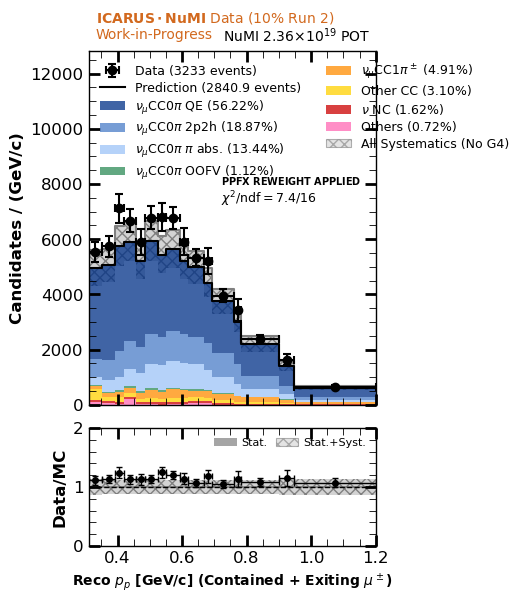

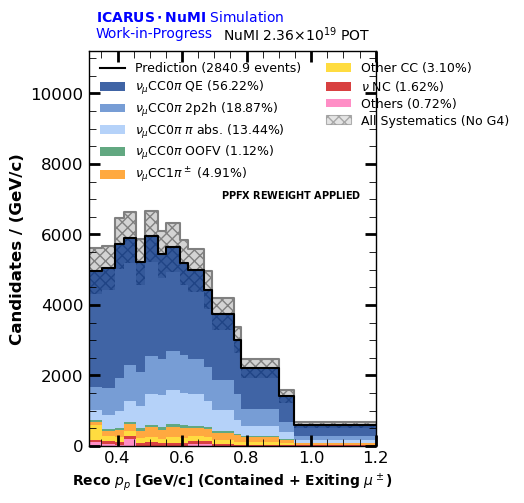

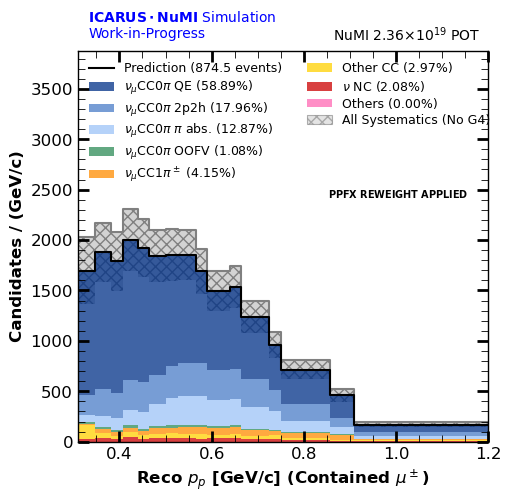

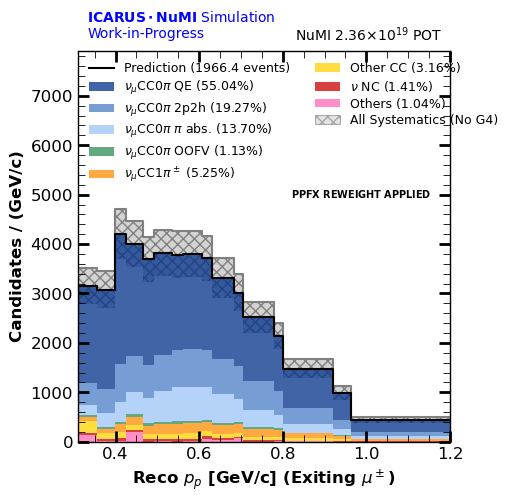

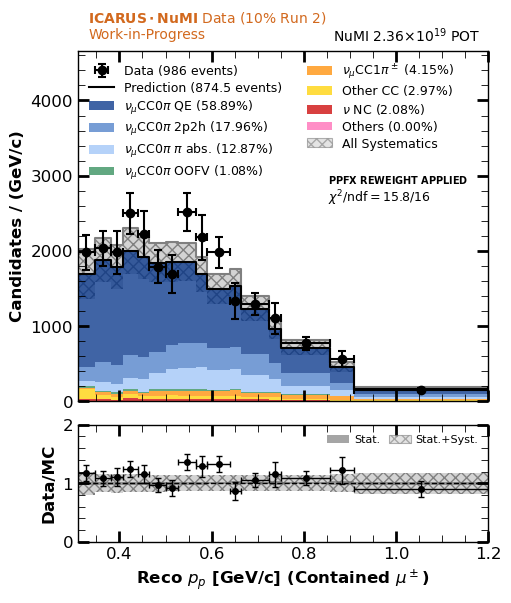

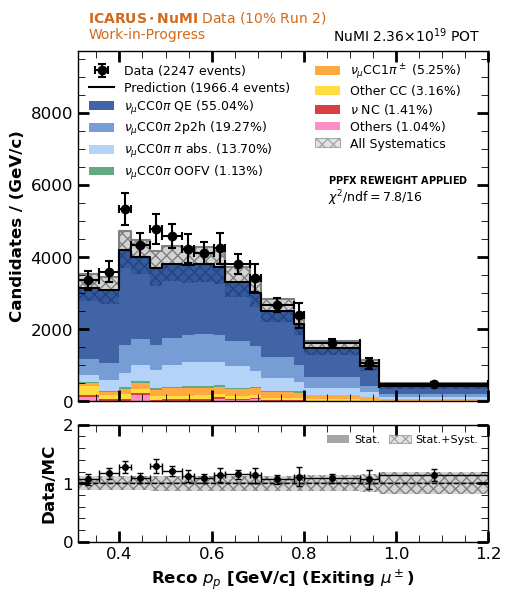

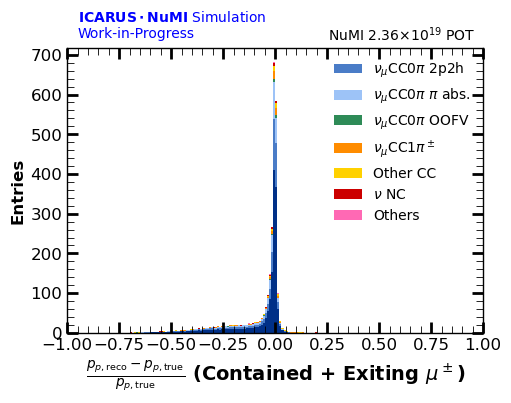

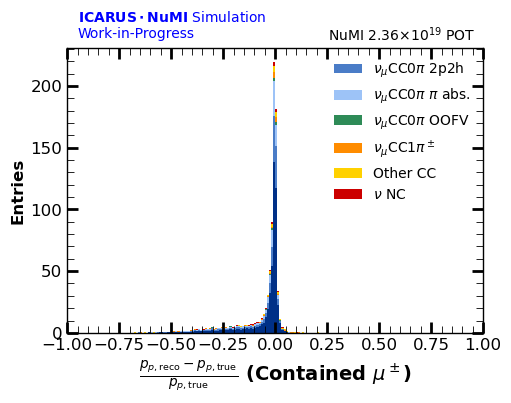

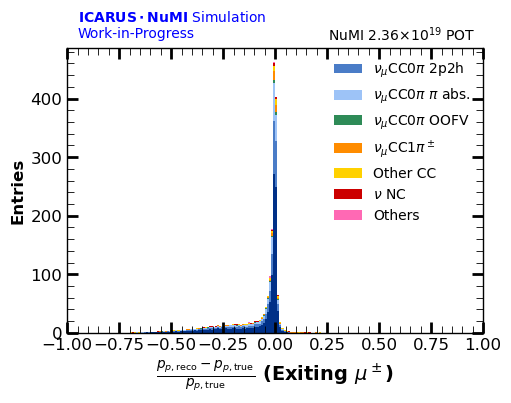

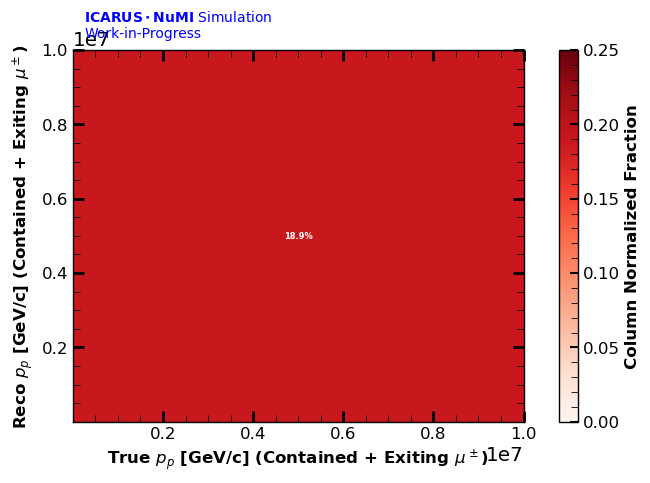

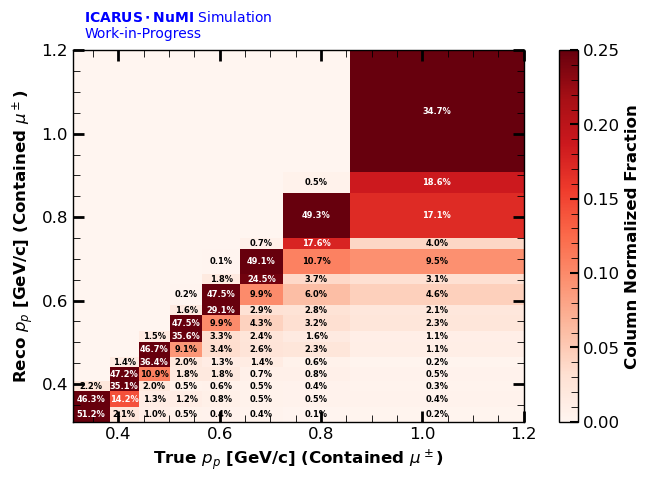

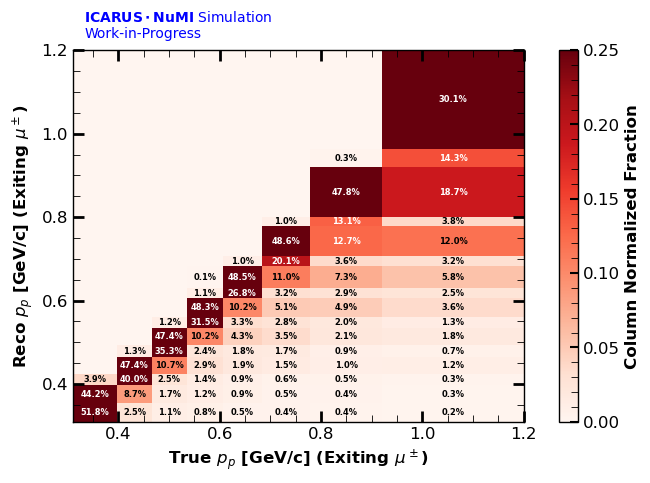

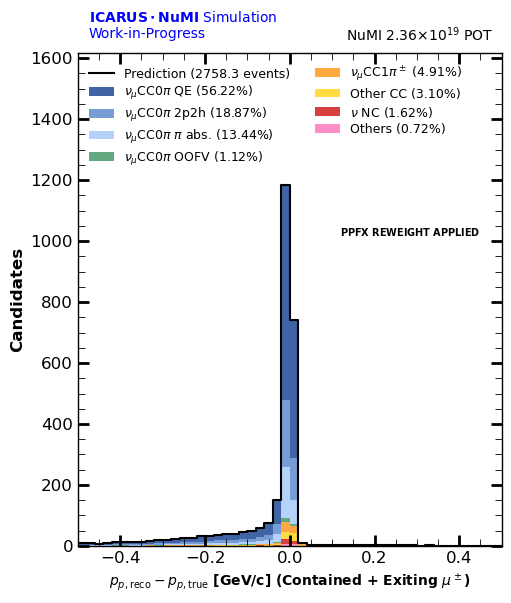

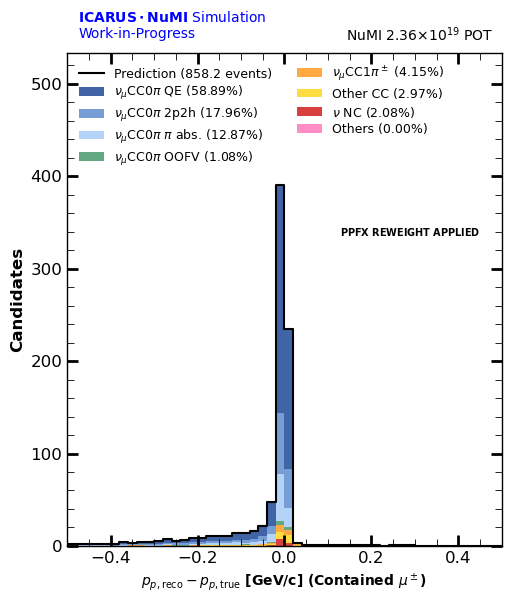

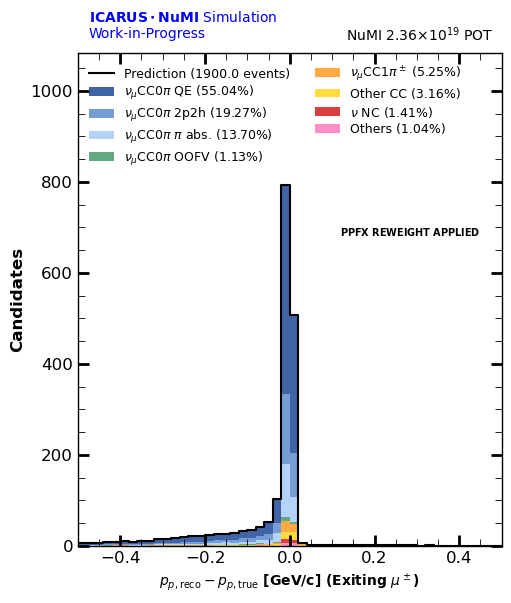

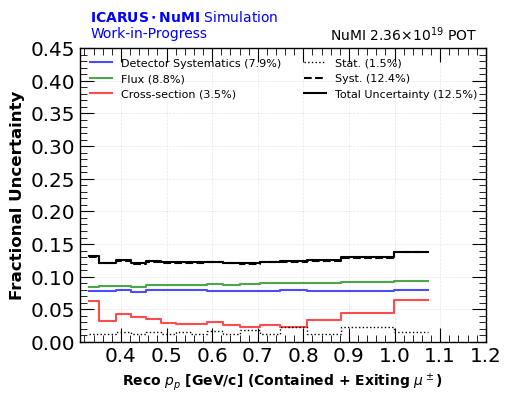

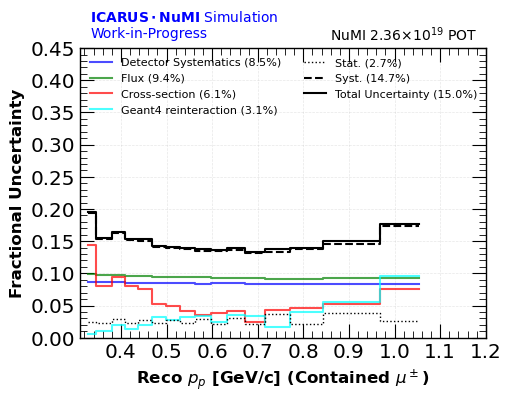

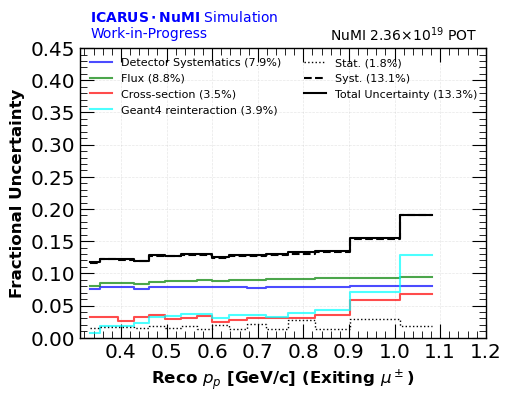

In [3]:
analysis = Analysis(ana_directory + '/leading_proton_momentum/leading_proton_momentum.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_pp          = tree['reco_leading_proton_momentum'].array(library='np')
    true_pp          = tree['true_leading_proton_momentum'].array(library='np')
    true_category    = tree['true_category'].array(library='np')
    proton_contained = tree['reco_leading_proton_containment'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_pp) &
    np.isfinite(reco_pp) &
    (reco_pp < 100) &
    (true_pp < 100)
)

# Compute absolute residual
abs_residual = reco_pp - true_pp

# Combined, contained, exiting masks
combined_mask  = signal_mask & valid_mask
contained_mask = signal_mask & valid_mask & (proton_contained == 1)
exiting_mask   = signal_mask & valid_mask & (proton_contained == 0)

# Binning
x_bins = np.linspace(0.25, 1.5, 16)
y_bins = np.linspace(-0.5, 0.5, 51)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.35)

titles = [
    r'Contained + Exiting $p$',
    r'Contained $p$',
    r'Exiting $p$'
]
masks = [combined_mask, contained_mask, exiting_mask]

for ax, mask, title in zip(axes, masks, titles):
    h, xedges, yedges = np.histogram2d(
        true_pp[mask],
        abs_residual[mask],
        bins=[x_bins, y_bins]
    )

    im = ax.imshow(
        h.T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        origin='lower',
        norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
        cmap='magma'
    )

    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(r'True $p_p$ [GeV/c]', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$p_{p,\mathrm{reco}} - p_{p,\mathrm{true}}$ [GeV/c]',
                  fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

plt.savefig('pdf/leading_proton_momentum_resolution_vs_true_momentum.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Leading proton momentum cross-section uncertainties
analysis = Analysis(ana_directory + '/leading_proton_momentum/leading_proton_momentum_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading proton momentum cross-section uncertainties expanded
analysis = Analysis(ana_directory + '/leading_proton_momentum/leading_proton_momentum_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading proton momentum flux uncertainties
analysis = Analysis(ana_directory + '/leading_proton_momentum/leading_proton_momentum_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading proton momentum flux uncertainties expanded
analysis = Analysis(ana_directory + '/leading_proton_momentum/leading_proton_momentum_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading proton momentum detector uncertainties
analysis = Analysis(ana_directory + '/leading_proton_momentum/leading_proton_momentum_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)